<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/Usecase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset
   mileage  engine_temp  brake_wear  tire_pressure  maintenance_required
0    20000           70          30             32                     0
1    35000           85          70             30                     1
2    15000           65          20             33                     0
3    50000           95          90             28                     1
4    42000           88          80             29                     1
5    30000           78          50             31                     0
6    27000           80          45             32                     0
7    39000           90          75             30                     1
8    10000           60          10             34                     0
9    45000           92          85             28                     1

Vehicle Clusters
   mileage  engine_temp  brake_wear  tire_pressure  maintenance_required  \
0    20000           70          30             32                     0   
1    35000         

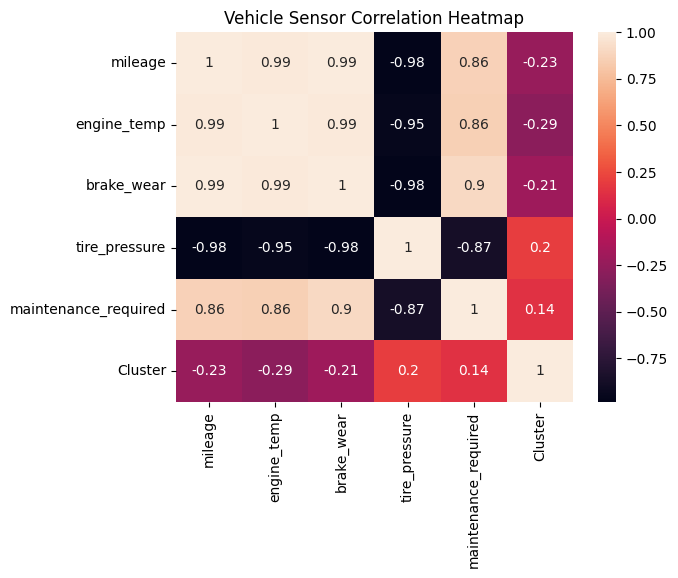

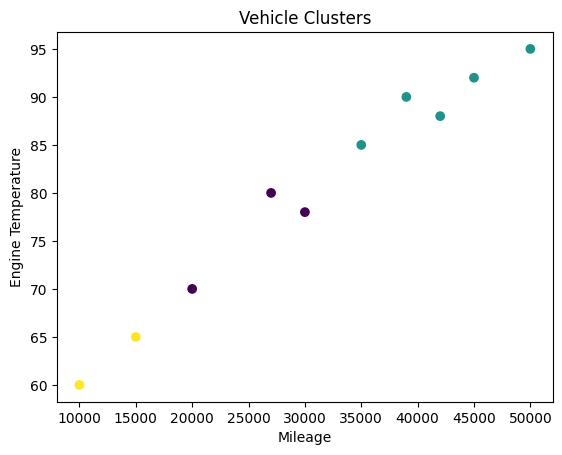

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# -----------------------------
# Step 1: Create Sample Dataset
# -----------------------------

data = {
    'mileage': [20000,35000,15000,50000,42000,30000,27000,39000,10000,45000],
    'engine_temp': [70,85,65,95,88,78,80,90,60,92],
    'brake_wear': [30,70,20,90,80,50,45,75,10,85],
    'tire_pressure': [32,30,33,28,29,31,32,30,34,28],
    'maintenance_required':[0,1,0,1,1,0,0,1,0,1]
}

df = pd.DataFrame(data)

print("Dataset")
print(df)

# -----------------------------
# Step 2: Data Preprocessing
# -----------------------------

# Handling missing values
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Feature Scaling
X = df_imputed.drop('maintenance_required', axis=1)
y = df_imputed['maintenance_required']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Step 3: Clustering Vehicles
# -----------------------------

kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nVehicle Clusters")
print(df)

# -----------------------------
# Step 4: Train/Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# -----------------------------
# Step 5: Perceptron Classifier
# -----------------------------

model = Perceptron()

params = {
    'max_iter':[500,1000,1500],
    'eta0':[0.001,0.01,0.1]
}

grid = GridSearchCV(model, params, cv=3)
grid.fit(X_train,y_train)

best_model = grid.best_estimator_

# -----------------------------
# Step 6: Prediction
# -----------------------------

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

# -----------------------------
# Step 7: Visualization
# -----------------------------

# Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Vehicle Sensor Correlation Heatmap")
plt.show()

# Cluster Plot
plt.figure()
plt.scatter(df['mileage'], df['engine_temp'], c=df['Cluster'])
plt.xlabel("Mileage")
plt.ylabel("Engine Temperature")
plt.title("Vehicle Clusters")
plt.show()